# SOLAQUA dataprocessing 

Here we convert "raw"-.bag files into desired sonar images. They are also exported

## (Optional) List Topics

In [1]:
from collections import defaultdict 
from rosbags.highlevel import AnyReader
from pathlib import Path
import numpy as np
import cv2
import re



# Change these two lines to switch dataset
DATA_BAG  = Path("../../solaqua_bags/2024-08-20_14-31-29_data.bag")   # sensor data
VIDEO_BAG = Path("../../solaqua_bags/2024-08-20_14-31-29_video.bag")  # camera and sonar video
VIDEO_FRAME = 0

print(f"Using data bag : {DATA_BAG.resolve()}")
print(f"Using video bag: {VIDEO_BAG.resolve()}")




def human_hz(count, duration_s):
    if count == 0 or duration_s <= 0:
        return 0.0
    return count / duration_s

for bag in [DATA_BAG, VIDEO_BAG]:
    print(f"\n=== {bag.name} ===")
    if not bag.exists():
        print("  (missing)")
        continue

    counts = defaultdict(int)
    first_ts = defaultdict(lambda: None)
    last_ts  = defaultdict(lambda: None)
    types = {}

    with AnyReader([bag]) as r:
        for c in r.connections:
            types[c.topic] = c.msgtype
        for conn, ts, _ in r.messages():
            t = conn.topic
            counts[t] += 1
            if first_ts[t] is None or ts < first_ts[t]:
                first_ts[t] = ts
            if last_ts[t] is None or ts > last_ts[t]:
                last_ts[t] = ts

    if not counts:
        print("  (no messages)")
        continue

    col_topic = max(len(t) for t in counts.keys())
    col_type  = max(len(types.get(t, "")) for t in counts.keys())
    header = f"{'TOPIC'.ljust(col_topic)}  {'TYPE'.ljust(col_type)}  COUNT    START(ns)          END(ns)            DURATION(s)  ~HZ"
    print(header)
    print("-" * len(header))

    for t in sorted(counts.keys()):
        n = counts[t]
        t0 = first_ts[t]
        t1 = last_ts[t]
        dur_s = (t1 - t0) / 1e9 if (t0 is not None and t1 is not None) else 0.0
        hz = human_hz(n, dur_s)
        print(
            f"{t.ljust(col_topic)}  "
            f"{types.get(t,'').ljust(col_type)}  "
            f"{str(n).rjust(5)}    "
            f"{str(t0).rjust(16)}  "
            f"{str(t1).rjust(16)}  "
            f"{dur_s:11.3f}  {hz:5.2f}"
        )

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/cluster/home/henrban/aquaculture-perception/.venv/lib64/python3.9/site-packages/traitlets/traitlets.py", line 632, in get
    value = obj._trait_values[self.name]
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/cluster/home/henrban/aquaculture-perception/.venv/lib64/python3.9/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/cluster/home/henrban/aquaculture-perception/.venv/lib64/python3.9/site-packages/ipykernel/kernelbase.py", line 301, in dispatch_control
    async with self._control_lock:
  File "/cluster/home/henrban/aquaculture-perception/.venv/lib64/python3.9/site-packages/traitlets/traitlets.py", line 687, in __get__
    return t.cast(G, self.get(obj, cls))  # the G should encode the Optional
  File "/cluster/home/henrban/aquaculture-percepti

Using data bag : /cluster/home/henrban/aquaculture-perception/data-processing/solaqua_bags/2024-08-20_14-31-29_data.bag
Using video bag: /cluster/home/henrban/aquaculture-perception/data-processing/solaqua_bags/2024-08-20_14-31-29_video.bag

=== 2024-08-20_14-31-29_data.bag ===
TOPIC                                     TYPE                                     COUNT    START(ns)          END(ns)            DURATION(s)  ~HZ
--------------------------------------------------------------------------------------------------------------------------------------------------
/bluerov2/alive                           std_msgs/msg/Float32                       129    1724157094493788400  1724157158270660900       63.777   2.02
/bluerov2/armed                           std_msgs/msg/Float32                       131    1724157093740108300  1724157158270716300       64.531   2.03
/bluerov2/battery                         messages/msg/BatteryStatus                  60    1724157095568144200  17241571

# Sonar data processing

What we want is raw sonar data processed to RGB images (and later grayscale that looks similar to cfc_gray).

### Setup 

In [2]:
from __future__ import annotations
from dataclasses import dataclass
from typing import Dict
import hashlib
import json

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from configs.cfc_gray_config import cfc_gray_config


SONAR_IMAGES_CONFIG = cfc_gray_config

### Load data (one frame)

In [3]:
from pathlib import Path
from utils.loader import load_sonoptix_frame_from_bag

# Change these two lines to switch dataset
DATA_BAG  = Path("../../solaqua_bags/2024-08-20_13-55-34_data.bag")   # sensor data
VIDEO_BAG = Path("../../solaqua_bags/2024-08-20_13-55-34_video.bag")  # camera and sonar video
VIDEO_FRAME = 0

M_raw, t_ns = load_sonoptix_frame_from_bag(VIDEO_BAG, VIDEO_FRAME)  # returns M_raw and timestamp
print("loaded:", M_raw.shape, M_raw.dtype, ". min..max:", float(M_raw.min()), float(M_raw.max()))
print("M_raw:")
print(M_raw)
print("timestamp: ", t_ns)  

loaded: (1024, 256) float32 . min..max: 0.0 59.0
M_raw:
[[ 7.  7.  8. ...  7.  7.  4.]
 [ 8.  9. 10. ... 10. 10.  8.]
 [ 5.  6.  7. ...  9.  9.  9.]
 ...
 [ 0.  0.  0. ...  0.  0.  0.]
 [ 0.  0.  0. ...  0.  0.  0.]
 [ 0.  0.  0. ...  0.  0.  0.]]
timestamp:  1724154937043114100


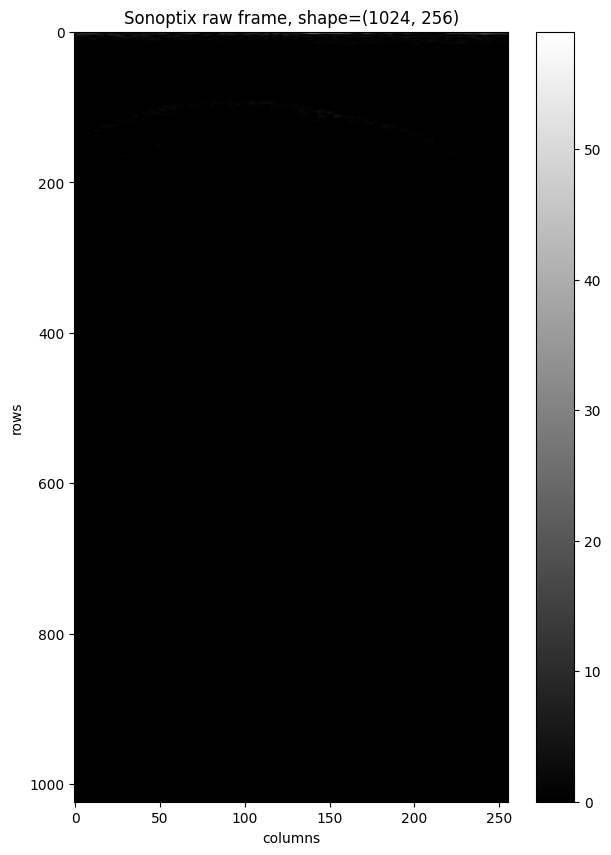

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 10))
plt.imshow(M_raw, cmap="gray", aspect="auto")
plt.title(f"Sonoptix raw frame, shape={M_raw.shape}")
plt.xlabel("columns")
plt.ylabel("rows")
plt.colorbar()
plt.show()


#### Plot raw and enhanced data, Polar from

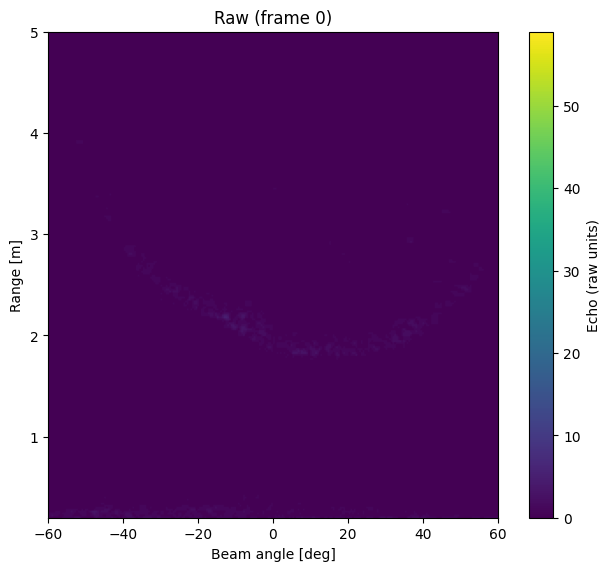

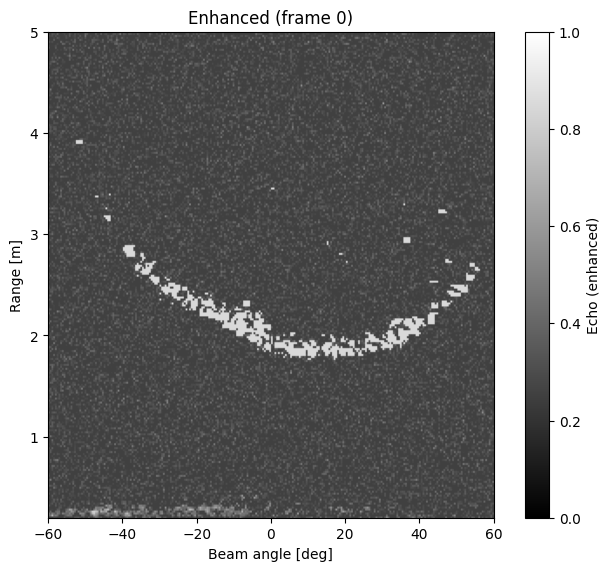

In [5]:
from utils.sonar_visualization import plot_raw_frame, plot_enhanced_frame, enhance_intensity, enhance_cfc_style


# fig = plot_raw_and_enhanced(M_raw, VIDEO_FRAME, SONAR_VIS_DEFAULTS)
fig1 = plot_raw_frame(M_raw, VIDEO_FRAME, SONAR_IMAGES_CONFIG)
fig2 = plot_enhanced_frame(M_raw, VIDEO_FRAME, SONAR_IMAGES_CONFIG, enhancer=enhance_cfc_style)
plt.show()


### Plot Cone display

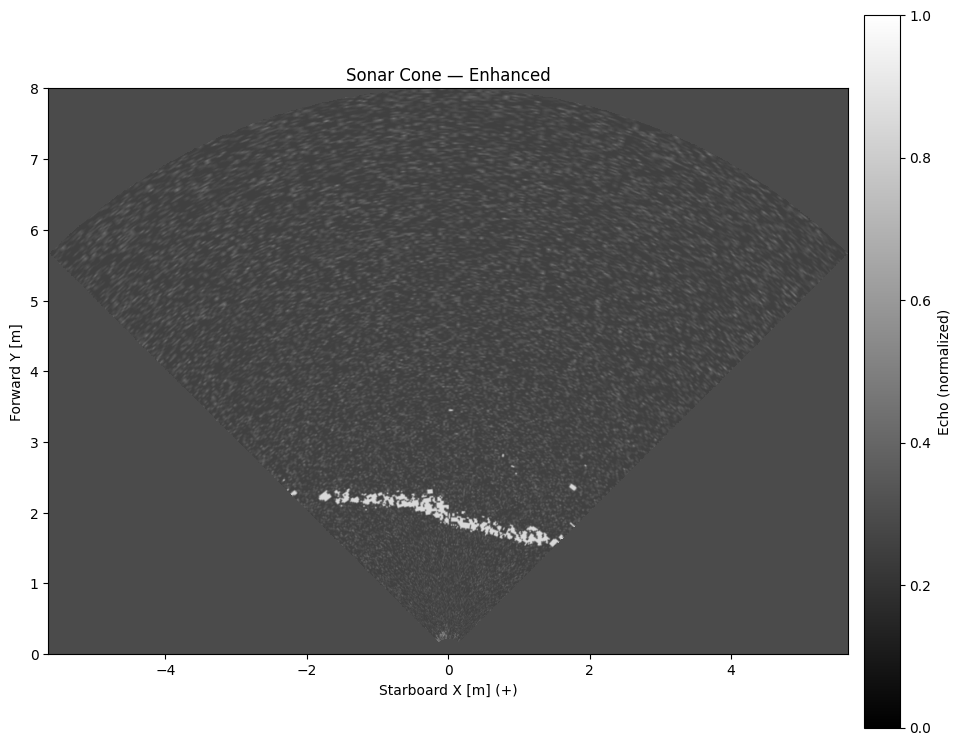

In [6]:
from utils.sonar_visualization import plot_cone_view, enhance_intensity, enhance_cfc_style


fig_cone = plot_cone_view(
    M_raw, 
    SONAR_IMAGES_CONFIG,
    use_enhanced=True,
    enhancer=enhance_cfc_style,   
)
plt.show()


# Export data (remember to set output name)



In [7]:
# from utils.sonar_visualization import save_cone_view_image, enhance_cfc_style

# save_cone_view_image(
#     M_raw,
#     SONAR_IMAGES_CONFIG,
#     out_path="exports/sonar/001_frame.png",
#     use_enhanced=True,
#     enhancer=enhance_cfc_style,
# )


### exporting all images

In [8]:
# export script
from itertools import islice
from pathlib import Path
from tqdm import tqdm
import numpy as np

from utils.loader import iter_sonoptix_frames_from_bag
from utils.sonar_visualization import save_cone_view_image, enhance_cfc_style

bag_stem = VIDEO_BAG.stem.replace("_video", "")
OUT_DIR = Path("raw_processed/all_images/") / bag_stem 
OUT_DIR.mkdir(parents=True, exist_ok=True)

START_FRAME = 0
END_FRAME   = 770
STEP        = 1
ENHANCER    = enhance_cfc_style
CFG         = SONAR_IMAGES_CONFIG

frame_iter = islice(iter_sonoptix_frames_from_bag(VIDEO_BAG), START_FRAME, END_FRAME, STEP)
n_out = max(0, (END_FRAME - START_FRAME + STEP - 1) // STEP)

for k, (M_raw, t_ns) in enumerate(tqdm(frame_iter, total=n_out, desc="Exporting frames")):
    frame_idx = START_FRAME + k * STEP

    if M_raw is None or not isinstance(M_raw, np.ndarray):
        tqdm.write(f"⚠️ Empty frame {frame_idx}")
        continue

    out_path = OUT_DIR / f"{t_ns}.jpg"
    save_cone_view_image(
        M_raw,
        CFG,
        out_path=out_path,
        use_enhanced=True,
        enhancer=ENHANCER,
    )

print("✅ Finished exporting all frames.")

Exporting frames:   0%|          | 0/770 [00:00<?, ?it/s]

Exporting frames: 100%|██████████| 770/770 [01:26<00:00,  8.93it/s]

✅ Finished exporting all frames.


### making mp4 from images

We are using Variable frame rate (VFR) and the ffmpeg library.

Was a bit tricky to get the ffmpeg dependency. I did module load Anaconda3/2024.02-1, then conda --version to confirm. Then conda create -n myffmpeg -c conda-forge ffmpeg -y to install ffmpeg. conda activate myffmpeg and ffmpeg -version to confirm. To load it into the .venv i did: source .venv/bin/activate and then export PATH="$HOME/.conda/envs/myffmpeg/bin:$PATH". Lastly select kernel with the python enviornment (.venv).

To activate environments next time do:
- module load Anaconda3/2024.02-1
- source .venv/bin/activate
- export PATH="$HOME/.conda/envs/myffmpeg/bin:$PATH"
- select right kernel

- if kernel cant find ffmpeg, do this inside notebook:
```python

```

In [9]:
import os
os.environ["PATH"] = "/cluster/home/henrban/.conda/envs/myffmpeg/bin:" + os.environ["PATH"]
!ffmpeg -version

ffmpeg version 8.0 Copyright (c) 2000-2025 the FFmpeg developers
built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
configuration: --prefix=/cluster/home/henrban/.conda/envs/myffmpeg --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923993009/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923993009/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923993009/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923993009/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-libvpl --enable-vaapi --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx

In [10]:
from utils.sonar_visualization import build_vfr_mp4_from_ns_frames


#VIDEO_BAG = Path("data/bags/2024-08-20_13-57-42_video.bag")     # bag should be defined in the top
bag_stem  = VIDEO_BAG.stem.replace("_video", "")
sonar_frames = Path(f"raw_processed/all_images/{bag_stem}")
sonar_out    = Path(f"raw_processed/mp4s/{bag_stem}_cfc_style.mp4")   ## change output name if you want to

build_vfr_mp4_from_ns_frames(sonar_frames, sonar_out, crf=18, preset="slow")

Running: ffmpeg -y -f concat -safe 0 -i raw_processed/mp4s/2024-08-20_13-55-34_cfc_style.list.txt -fps_mode vfr -pix_fmt yuv420p -c:v libx264 -crf 18 -preset slow -movflags +faststart raw_processed/mp4s/2024-08-20_13-55-34_cfc_style.mp4


ffmpeg version 8.0 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/cluster/home/henrban/.conda/envs/myffmpeg --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923993009/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923993009/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923993009/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923993009/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-libvpl --enable-vaapi --enable-libopenvino --enable-gpl --enable-libx264 --enable-

✅ Wrote raw_processed/mp4s/2024-08-20_13-55-34_cfc_style.mp4
🧹 Deleted temporary file: 2024-08-20_13-55-34_cfc_style.list.txt


[mp4 @ 0x560550637bc0] Starting second pass: moving the moov atom to the beginning of the file
[out#0/mp4 @ 0x5605506379c0] video:41904KiB audio:0KiB subtitle:0KiB other streams:0KiB global headers:0KiB muxing overhead: 0.027462%
frame=  771 fps= 22 q=-1.0 Lsize=   41915KiB time=00:00:49.24 bitrate=6973.4kbits/s speed=1.43x elapsed=0:00:34.48    
[libx264 @ 0x56055063e9c0] frame I:5     Avg QP:13.64  size: 63538
[libx264 @ 0x56055063e9c0] frame P:735   Avg QP:19.07  size: 55605
[libx264 @ 0x56055063e9c0] frame B:31    Avg QP:20.29  size: 55524
[libx264 @ 0x56055063e9c0] consecutive B-frames: 94.6%  0.3%  0.0%  5.2%
[libx264 @ 0x56055063e9c0] mb I  I16..4: 18.9% 81.1%  0.0%
[libx264 @ 0x56055063e9c0] mb P  I16..4:  0.1% 42.7%  0.5%  P16..4:  5.9%  5.7%  5.1%  0.0%  0.0%    skip:40.1%
[libx264 @ 0x56055063e9c0] mb B  I16..4:  0.0% 24.0%  2.1%  B16..8:  7.7% 15.0%  8.0%  direct: 2.7%  skip:40.6%  L0:40.2% L1:24.6% BI:35.2%
[libx264 @ 0x56055063e9c0] 8x8 transform intra:98.2% inter:97.6%
[

PosixPath('raw_processed/mp4s/2024-08-20_13-55-34_cfc_style.mp4')